<a href="https://colab.research.google.com/github/jfpa11100/E-Sports-ML/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 1: E-Sports Biometrics & Performance
## Predicción del resultado de partidas (Win/Loss) a partir de biométricas y métricas ambientales de jugadores de e-sports

**Curso:** Inteligencia Artificial

**Universidad:** Universidad de Medellín (UdeM)

**Profesor:** Antonio Jesús Tamayo Herrera

**Semestre:** 2026-1

**Integrantes:**
- Mariana Pineda Isaza
- Juan Pablo Ramírez
- Juan Felipe Palacio

---

### Descripción del proyecto

Este proyecto utiliza el dataset **[E-Sports Biometrics & Performance](https://www.kaggle.com/datasets/sarveshchhetri/e-sports-biometrics-and-performance)** de Kaggle, un conjunto de datos sintético de 250,000 registros diseñado para simular factores fisiológicos y ambientales reales que afectan a atletas de e-sports (élite y casuales).

El dataset mide cómo métricas biológicas como el ritmo cardíaco, la fatiga y el sueño impactan el rendimiento dentro del juego y el resultado de las partidas, un tema relevante para la ciencia del deporte aplicada a los e-sports, un campo en crecimiento junto con la industria.

**Problema:** Clasificación binaria — predecir la variable `Match_Outcome` (Win / Loss) a partir del estado biológico y ambiental de un jugador previo a la partida (edad, horas de sueño, energizantes consumidos, brillo de pantalla, ritmo cardíaco, HRV, APM, tiempo de reacción, entre otras).

# Descripción del dataset:

| Column_Name       | Description                                                                                                                                          |
|-------------------|------------------------------------------------------------------------------------------------------------------------------------------------------|
| Player_ID         | A unique alphanumeric identifier for each gamer.                                                                                                     |
| Age               | The age of the player, ranging from 16 to 40 years old.                                                                                              |
| Game_Genre        | The category of the game played during the session (MOBA, FPS, Battle Royale, or Fighting).                                                          |
| PlayTime_Hours    | The duration of the current gaming session in hours, used to measure fatigue.                                                                        |
| Sleep_Hours       | The number of hours the player slept the night before the session.                                                                                   |
| Energy_Drinks     | The number of energy drinks (caffeine) consumed before or during the match.                                                                          |
| Screen_Brightness | The brightness setting of the player's monitor as a percentage (contains ~5% missing values).                                                        |
| Blue_Light_Filter | Indicates whether a blue light filter was active on the screen (Yes / No).                                                                           |
| APM               | Actions Per Minute. A measure of how many inputs (clicks/keystrokes) the player performs per minute.                                                 |
| Heart_Rate_BPM    | The player's average heart rate in beats per minute during the match.                                                                                |
| HRV_Score         | Heart Rate Variability score (10-100). Higher scores generally indicate less physiological stress and better recovery (contains ~2% missing values). |
| Reaction_Time_ms  | The player's average reaction time measured in milliseconds (ms).                                                                                    |
| Match_Outcome     | The final result of the gaming match (Win / Loss).                                                                                                   |


# Análisis exploratorio de datos (EDA)

In [5]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
import pandas as pd
import os

file_path_drive = '/content/drive/MyDrive/AI enfasis/Proyecto 1/esports_gaming_biometrics_250k.csv'

# Verifica si el archivo existe antes de intentar cargarlo
if os.path.exists(file_path_drive):
    df = pd.read_csv(file_path_drive)
    print("Dataset cargado exitosamente.")
    display(df.head())
else:
    print(f"Error: Archivo no encontrado en {file_path_drive}!")
    df = pd.DataFrame()

Dataset cargado exitosamente.


,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss


In [49]:
# Eliminamos el Player ID ya que no aporta al modelo
del df["Player_ID"]

In [46]:
df.describe()

,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms
count,250000.000000,250000.000000,250000.000000,250000.000000,237452.000000,250000.000000,250000.000000,245066.000000,250000.000000
mean,22.588136,2.527753,6.500900,0.917720,54.918735,204.076168,84.062784,87.479087,262.900538
std,3.829706,2.358799,1.495851,1.045559,25.965989,77.004233,9.670229,11.063101,19.096927
min,16.000000,0.500000,2.000000,0.000000,10.000000,30.000000,60.000000,25.510000,175.170000
25%,20.000000,0.720000,5.490000,0.000000,32.500000,143.000000,77.000000,80.590000,249.930000
50%,23.000000,1.730000,6.500000,1.000000,54.900000,192.000000,84.000000,89.190000,262.590000
75%,25.000000,3.470000,7.510000,1.000000,77.400000,263.000000,90.000000,97.260000,275.600000
max,40.000000,12.000000,11.000000,4.000000,100.000000,563.000000,129.000000,100.000000,355.470000


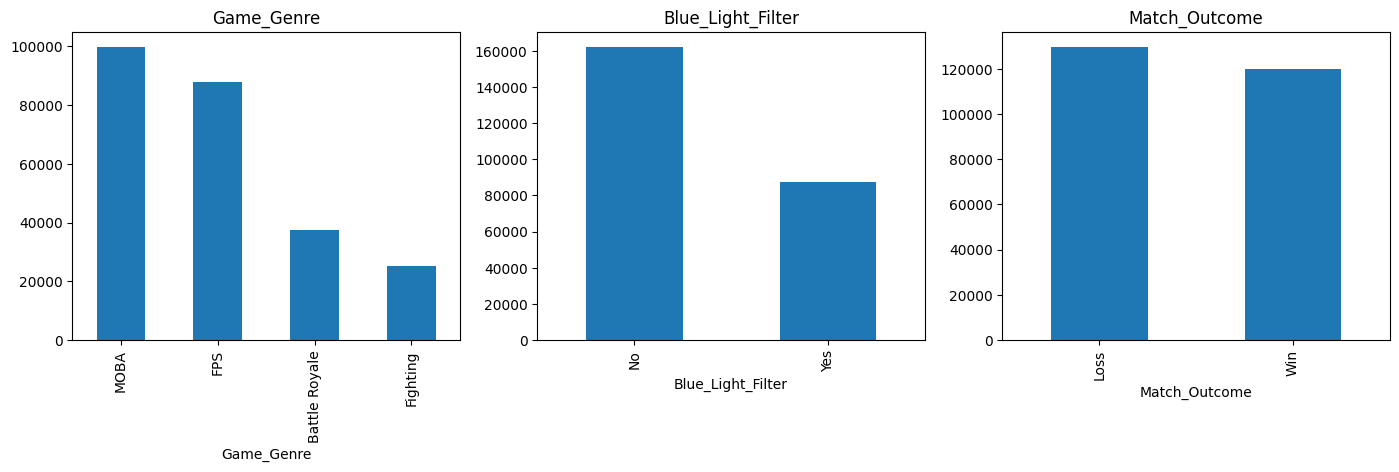

In [47]:
import matplotlib.pyplot as plt

cat_cols = ['Game_Genre', 'Blue_Light_Filter', 'Match_Outcome']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(17, 4))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)



In [15]:
df_sin_nan = df.dropna()

In [16]:
df_sin_nan.describe()

,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms
count,232793.000000,232793.000000,232793.000000,232793.000000,232793.000000,232793.000000,232793.000000,232793.000000,232793.000000
mean,22.587599,2.527273,6.500865,0.917768,54.926060,204.075930,84.064405,87.483066,262.894261
std,3.827776,2.358285,1.494328,1.045498,25.971237,77.026326,9.670104,11.062988,19.084101
min,16.000000,0.500000,2.000000,0.000000,10.000000,30.000000,60.000000,25.510000,175.170000
25%,20.000000,0.720000,5.490000,0.000000,32.500000,143.000000,77.000000,80.590000,249.940000
50%,23.000000,1.730000,6.500000,1.000000,54.900000,192.000000,84.000000,89.200000,262.580000
75%,25.000000,3.470000,7.510000,1.000000,77.400000,263.000000,90.000000,97.270000,275.570000
max,40.000000,12.000000,11.000000,4.000000,100.000000,563.000000,129.000000,100.000000,355.470000


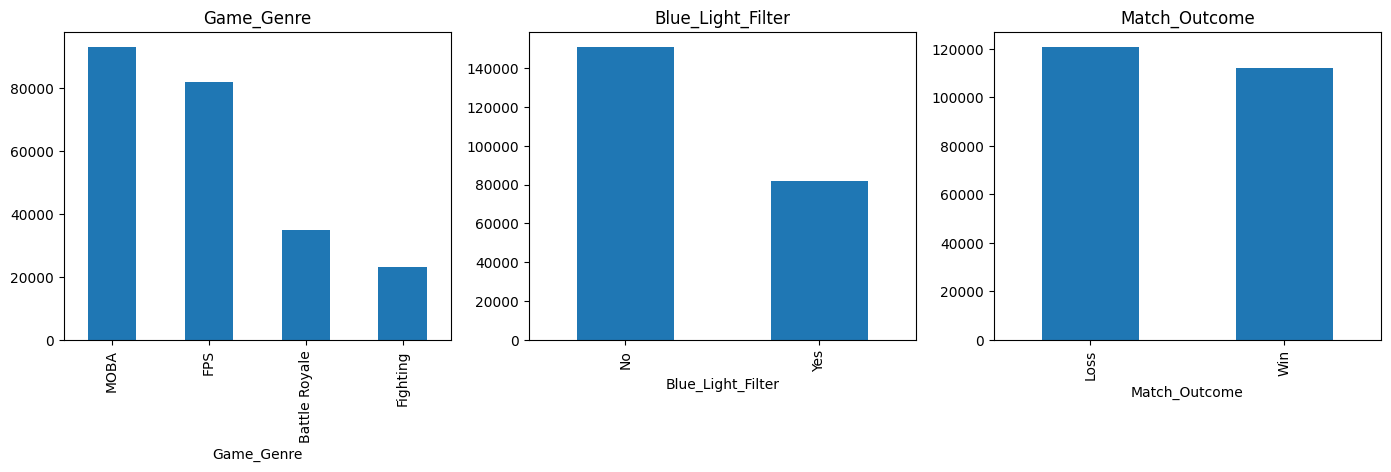

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(17, 4))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    df_sin_nan[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)

Analizando: Como al eliminar los datos nulos, las variables no cambian su distribución es una buena decisión modificar el dataset y no imputar datos nulos

In [ ]:
df = df_sin_nan

# Preprocesamiento

# Entrenamiento con Regresión Logística
Validación cruzada (10 folds)

# Entrenamiento con SVM
Validación cruzada (10 folds)

#

# Comparación de modelos Regresión logística vs SVM